<a href="https://colab.research.google.com/github/emzu/Kigali-Global-Flood-Models/blob/main/CHIRPS_Data_Download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization


In [1]:
!pip install xarray rioxarray

In [11]:
import requests
from datetime import datetime, timedelta
import os
import gzip
import shutil

import xarray as xr
import rioxarray
import pandas as pd
import numpy as np
from pathlib import Path

def uncompress_gz_file(gz_filepath, remove_gz=True):
    """
    Uncompress a .gz file

    Parameters:
    -----------
    gz_filepath : str
        Path to the .gz file
    remove_gz : bool
        Whether to remove the .gz file after uncompressing (default: True)

    Returns:
    --------
    str : Path to the uncompressed file
    """
    output_filepath = gz_filepath[:-3]  # Remove .gz extension

    try:
        with gzip.open(gz_filepath, 'rb') as f_in:
            with open(output_filepath, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        print(f"Uncompressed: {os.path.basename(output_filepath)}")

        # Optionally remove the .gz file to save space
        if remove_gz:
            os.remove(gz_filepath)
            print(f"Removed: {os.path.basename(gz_filepath)}")

        return output_filepath

    except Exception as e:
        print(f"Failed to uncompress {gz_filepath}: {e}")
        return None

def extract_timeseries_from_netcdf(ds, stations):
    """
    Extract time series from NetCDF file at station locations
    """
    # Open dataset
    #ds = xr.open_dataset(netcdf_file)

    results = {}
    for station_name, (lon, lat) in stations.items():
        # Select nearest pixel
        ts = ds.sel(x=lon, y=lat, method='nearest')
        results[station_name] = ts['precipitation'].values.flatten()

    # Convert to DataFrame
    df = pd.DataFrame(results, index=ds.time.values)

    return df

def create_chirps_netcdf(tif_directory, output_file, year):
    """
    Combine all daily CHIRPS TIFs into a single NetCDF file
    This is a one-time preprocessing step
    """
    tif_files = sorted(Path(tif_directory).glob(f"chirps-v2.0.{year}.*.tif"))

    # Extract dates from filenames
    dates = [datetime.strptime(".".join(f.stem.split('.')[-3:]), '%Y.%m.%d') for f in tif_files]

    # Load all files (lazy loading)
    datasets = []
    for tif_file in tif_files:
        da = rioxarray.open_rasterio(tif_file, masked=True)
        datasets.append(da)

    # Concatenate along time dimension
    combined = xr.concat(datasets, dim='time')
    combined['time'] = dates
    combined = combined.where(combined != -9999)
    combined = combined.to_dataset(name='precipitation')

    # Add metadata
    combined.attrs['units'] = 'mm/day'
    combined.attrs['source'] = 'CHIRPS v2.0'

    # Save to NetCDF
    combined.to_netcdf(output_file)

    return combined


# Run

In [ ]:
# Setup
year = 2022
base_url = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_daily/tifs/p05"
output_dir = f"chirps_data/{year}"
os.makedirs(output_dir, exist_ok=True)

# Download daily files
start_date = datetime(year, 1, 1)
end_date = datetime(year, 12, 31)

current_date = start_date
while current_date <= end_date:
    # CHIRPS naming convention: chirps-v2.0.YYYY.MM.DD.tif.gz
    filename = f"chirps-v2.0.{current_date.strftime('%Y.%m.%d')}.tif.gz"
    url = f"{base_url}/{year}/{filename}"
    output_path = os.path.join(output_dir, filename)

    # Check if uncompressed file already exists
    uncompressed_path = output_path[:-3]  # Remove .gz
    if not os.path.exists(uncompressed_path) and not os.path.exists(output_path):
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()

            with open(output_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"Downloaded: {filename}")

            # Uncompress the file
            uncompress_gz_file(output_path, remove_gz=True)

        except requests.exceptions.RequestException as e:
            print(f"Failed to download {filename}: {e}")
    else:
        print(f"Skipping {filename} - already exists")

    current_date += timedelta(days=1)

# Save as Combine NetCDF
chirps_nc = create_chirps_netcdf(f'chirps_data/{year}', f'chirps_{year}.nc', year)

In [6]:
# Save compressed NetCdf
ds0 = xr.open_dataset('chirps_2021.nc')
ds1 = xr.open_dataset('chirps_2022.nc')
ds2 = xr.open_dataset('chirps_2023.nc')
ds3 = xr.open_dataset('chirps_2024.nc')

# Concatenate along time dimension
ds = xr.concat([ds0, ds1, ds2, ds3], dim='time')
encoding = {
    'precipitation': {
        'zlib': True,
        'complevel': 5,
        'dtype': 'float32',
        '_FillValue': -9999.0
    }
}

ds.to_netcdf("chirps_Africa_2020_2024.nc", encoding=encoding)

In [8]:
## Extract Time-Series at Station Location
Gitega_loc = [30.06, -1.96]
stations = {'Gitega': (30.06, -1.96)}

check = extract_timeseries_from_netcdf(ds, stations)
check.to_csv('Gitega_chirps.csv')

## Visualize Data

<Axes: >

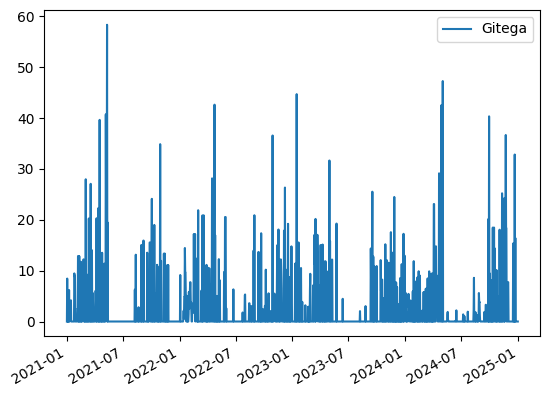

In [9]:
check.plot()

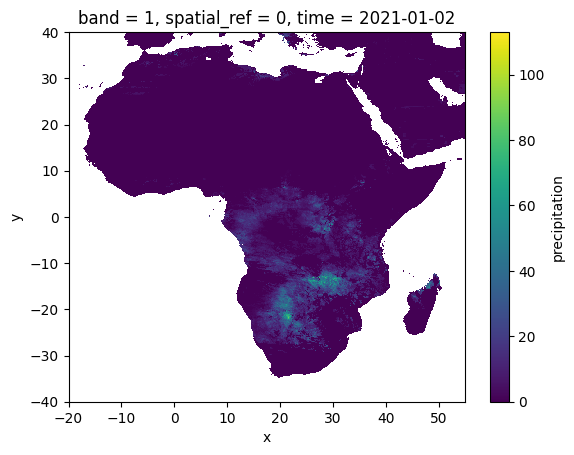

In [ ]:
ds.sel(band = 1, time = '2021-01-02')['precipitation'].plot()